# Session 7 — Rotary Positional Embeddings (RoPE)

**Recap:** none of the attention variants so far encoded token *position* --
attention as derived in Notebook 0 is permutation-invariant without it. RoPE
is how position enters the picture, and it's the mechanism MLA's decoupled
path (Notebook 6) had to work around.


## Derivation intuition

RoPE rotates each Q/K vector (in 2D subspace pairs) by an angle proportional
to its position. Because rotating both Q and K by their respective
positions, then taking a dot product, the result depends only on the
**difference** in positions (relative position) — not on either position
absolutely. This is a clean way to inject position without adding it as a
separate term.


In [1]:
import math
import torch

# Hand-rotate a single 2D vector by 30 degrees, by hand, then verify with torch.
angle = math.radians(30)
v = torch.tensor([1.0, 0.0])
rotation_matrix = torch.tensor([
    [math.cos(angle), -math.sin(angle)],
    [math.sin(angle), math.cos(angle)],
])
rotated = rotation_matrix @ v
print("original vector:", v.tolist())
print("rotated 30 degrees:", rotated.tolist())
print("norm preserved:", torch.allclose(v.norm(), rotated.norm(), atol=1e-6))


original vector: [1.0, 0.0]
rotated 30 degrees: [0.8660253882408142, 0.5]
norm preserved: True


In [2]:
from kv_cache_variants.rope import build_rope_cache, apply_rotary

torch.manual_seed(0)
head_dim, seq_len = 16, 8
cos, sin = build_rope_cache(head_dim, seq_len)
q = torch.randn(1, 2, seq_len, head_dim)
rotated = apply_rotary(q, cos, sin)

print("rotation preserves vector norm (rotation is orthogonal):",
      torch.allclose(rotated.norm(dim=-1), q.norm(dim=-1), atol=1e-4))


rotation preserves vector norm (rotation is orthogonal): True


## Incremental rotation matches full recompute

Rotating a single new token at `offset=seq_len` must match rotating the full
extended sequence and slicing the last position -- this is what makes RoPE
compatible with incremental decoding.


In [3]:
cos2, sin2 = build_rope_cache(head_dim, seq_len + 1)
q_next = torch.randn(1, 2, 1, head_dim)
full = torch.cat([q, q_next], dim=2)
rotated_full = apply_rotary(full, cos2, sin2)
rotated_next = apply_rotary(q_next, cos2, sin2, offset=seq_len)
matches = torch.allclose(rotated_full[:, :, -1:, :], rotated_next, atol=1e-5)
print("incremental single-token rotation matches full recompute:", matches)
assert matches


incremental single-token rotation matches full recompute: True


## Context-extension strategies

Models are trained at some `trained_max_len`. Running them at longer
sequences means RoPE must extrapolate to positions/frequencies never seen in
training, which degrades quality unless corrected:

- **Linear / Position Interpolation** (Chen et al., 2023): compress positions
  by a fixed scale factor so the model "sees" positions within its trained
  range.
- **Dynamic NTK** (community/EleutherAI, 2023): stretch the rotation
  frequency base itself, only once `seq_len` exceeds the trained context.
- **YaRN** (Peng et al., 2023): a per-frequency ramp — low frequencies
  (long-range) get linearly interpolated, high frequencies (local, short-
  range) are left untouched, avoiding the local-attention quality loss that
  pure linear scaling causes.


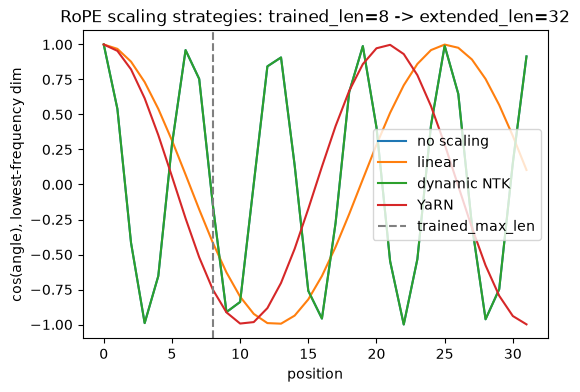

In [4]:
from kv_cache_variants.rope import linear_scaled_rope_cache, dynamic_ntk_rope_cache, yarn_rope_cache
import matplotlib.pyplot as plt

trained_len, extended_len = 8, 32
linear_cos, _ = linear_scaled_rope_cache(head_dim, extended_len, scale_factor=extended_len / trained_len)
ntk_cos, _ = dynamic_ntk_rope_cache(head_dim, extended_len, trained_max_len=trained_len)
yarn_cos, _ = yarn_rope_cache(head_dim, extended_len, trained_max_len=trained_len,
                               scale_factor=extended_len / trained_len)
base_cos, _ = build_rope_cache(head_dim, extended_len)

plt.figure(figsize=(6, 4))
for name, table_cos in [("no scaling", base_cos), ("linear", linear_cos),
                         ("dynamic NTK", ntk_cos), ("YaRN", yarn_cos)]:
    plt.plot(table_cos[:, 0].numpy(), label=name)
plt.axvline(trained_len, linestyle="--", color="gray", label="trained_max_len")
plt.xlabel("position")
plt.ylabel("cos(angle), lowest-frequency dim")
plt.legend()
plt.title(f"RoPE scaling strategies: trained_len={trained_len} -> extended_len={extended_len}")
plt.show()


```mermaid
flowchart TD
    A[position index] --> B["angle = position x frequency"]
    B --> C[rotate Q/K pair]
    C --> D["dot product depends only on relative position"]
```


```mermaid
flowchart LR
    A[all frequencies] --> B{"YaRN ramp"}
    B -->|high frequency, local| C[unscaled]
    B -->|low frequency, long-range| D[linearly interpolated]
```


## Recap

RoPE encodes relative position via rotation, and extension strategies adapt
it for longer-than-trained contexts. This is the position mechanism every
attention variant in this course (MHA/GQA/MQA/MLA) can be combined with.

You are now ready to move to `08_flashattention.ipynb`.
